<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/07_explainable_ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[⬅ Back to the workshop index](https://github.com/lorenzkap/ML2026#-the-notebooks) · **Notebook 07 of the course**


# 🩺 Notebook 07 — Opening the black box with SHAP

> *"The model says this patient has a 71% risk of dying. **Why?**"* — every clinician, ever.

A model that predicts well but can't explain itself is hard to trust and impossible to
audit. In this notebook we pry open the black box of a gradient-boosted tree model and ask
it to **show its reasoning** — globally (which features matter across all patients) and for
**one individual patient at the bedside**.

**What you'll learn**
- The difference between a model's built-in feature importance and the more trustworthy **permutation importance**.
- What **SHAP** values are, in one plain sentence, and how to read a **beeswarm** summary plot.
- How to explain a **single patient's** prediction with a **waterfall** plot — the emotional highlight.
- How a **dependence plot** reveals the shape of a risk relationship (e.g. lactate → mortality).
- The honest **caveats**: SHAP explains the *model*, not the *biology*.

**⏱️ Time:** ≈50 min · **Prerequisites:** Notebook 05 (you should already be comfortable
training an XGBoost / random-forest classifier on the patient table).

## ⚙️ Run me first

Run the setup cell below once. It installs anything missing (including `shap` and `xgboost`),
sets a clean plotting style, and defines the data-loading helpers. *(You saw this cell in the
earlier notebooks — nothing new here, just run it.)*

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 👩‍🏫 INSTRUCTORS: put a direct-download link to the workshop data here (or set the
# WORKSHOP_DATA_URL environment variable) and participants never upload anything.
# It must be a folder-style base URL that serves the CSVs by name, e.g.
#     "https://your-institution.example/sepsis_workshop/"
# Leave it empty ("") to use the upload flow instead. The data is NOT in the public
# GitHub repo on purpose — it is derived from MIMIC-IV and covered by a PhysioNet DUA.
WORKSHOP_DATA_URL = os.environ.get("WORKSHOP_DATA_URL", "")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    paths = [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]
    cache = _drive_cache()
    if cache:
        paths.append(os.path.join(cache, name))
    for p in paths:
        if os.path.exists(p):
            return p
    return None

def _try_download(name):
    """If the instructor configured WORKSHOP_DATA_URL, fetch the file from there."""
    if not WORKSHOP_DATA_URL:
        return None
    import urllib.request
    url = WORKSHOP_DATA_URL.rstrip("/") + "/" + name
    try:
        print(f"⬇  downloading {name} …")
        urllib.request.urlretrieve(url, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV. Searches local folders, (in Colab) your Google-Drive cache, and
    the instructor's download link. If none of those work it asks you to upload the file
    ONCE, then saves a copy to Drive so the other notebooks find it automatically."""
    p = _find(name)
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)
    if p:
        data = pd.read_csv(p)
        print(f"✓ loaded {name}")
        _cache_to_drive(name, data)
        return data
    try:
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Ask your instructor for the workshop CSVs, then either "
            f"upload it when prompted, or put it next to this notebook / in a data/ folder."
        )


## 🧱 Load the patient table

We reuse the canonical patient-table builder from Notebook 04 (aggregates the 4-hourly
time-series into **one row per ICU stay**). If `sepsis_patients.csv` already exists it just
loads it; otherwise it builds it on the fly.

In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))

patients = load_patients()
print("patient table:", patients.shape)
patients.head(3)

✓ loaded data/sepsis_patients.csv
patient table: (1696, 107)


,icustayid,age,gender,elixhauser,re_admission,weight_kg,n_blocs,los_hours,mechvent_ever,vaso_max,fluid_balance_last,urine_total,HR_mean,HR_min,HR_max,HR_last,SysBP_mean,SysBP_min,SysBP_max,SysBP_last,MeanBP_mean,MeanBP_min,MeanBP_max,MeanBP_last,RR_mean,RR_min,RR_max,RR_last,SpO2_mean,SpO2_min,SpO2_max,SpO2_last,Temp_C_clean_mean,Temp_C_clean_min,Temp_C_clean_max,Temp_C_clean_last,GCS_mean,GCS_min,GCS_max,GCS_last,Creatinine_mean,Creatinine_min,Creatinine_max,Creatinine_last,BUN_mean,BUN_min,BUN_max,BUN_last,Arterial_lactate_mean,Arterial_lactate_min,Arterial_lactate_max,Arterial_lactate_last,WBC_count_mean,WBC_count_min,WBC_count_max,WBC_count_last,Platelets_count_mean,Platelets_count_min,Platelets_count_max,Platelets_count_last,Potassium_mean,Potassium_min,Potassium_max,Potassium_last,Sodium_mean,Sodium_min,Sodium_max,Sodium_last,Albumin_mean,Albumin_min,Albumin_max,Albumin_last,INR_mean,INR_min,INR_max,INR_last,Arterial_pH_mean,Arterial_pH_min,Arterial_pH_max,Arterial_pH_last,Shock_Index_mean,Shock_Index_min,Shock_Index_max,Shock_Index_last,SOFA_mean,SOFA_min,SOFA_max,SOFA_last,SIRS_mean,SIRS_min,SIRS_max,SIRS_last,PaO2_FiO2_mean,PaO2_FiO2_min,PaO2_FiO2_max,PaO2_FiO2_last,Hb_mean,Hb_min,Hb_max,Hb_last,Creatinine_delta,Arterial_lactate_delta,SOFA_delta,Shock_Index_delta,GCS_delta,morta_90,died_in_hosp
0,30003226,67,0,4,0,91.8,12,48,0,0.00,3679.19,625.0,73.3108,64.00,84.20,84.2,137.5183,114.75,169.50,137.0,95.4717,87.25,106.86,90.8,15.5775,12.75,20.8,20.8,96.6708,93.00,99.50,97.0,37.4842,36.67,37.98,36.67,15.0000,15.0,15.0,15.0,11.4490,0.6,12.4388,12.4388,54.4950,13.0,64.0,58.0,1.0617,0.6,2.0,1.7,7.7700,6.60,9.3000,6.6,220.8333,183.0,357.0,183.0,5.4108,2.9,6.80,5.4,135.2933,132.0,149.0,132.0,2.8583,2.30,3.3,3.3,1.4392,1.00,3.1,3.1,7.3458,7.22,7.45,7.32,0.5408,0.39,0.65,0.61,4.8333,1,7,5,0.1667,0,1,1,387.0475,177.78,1342.86,200.00,7.0667,6.6,8.00,6.6,11.8388,-0.3,4,0.02,0.0,0,0
1,30004576,36,0,2,0,87.0,7,28,0,0.00,-2170.00,2350.0,95.7071,89.00,108.33,89.0,126.0271,121.00,138.83,121.0,82.4829,79.00,88.86,79.0,16.5686,12.40,24.0,24.0,97.6457,96.00,99.00,99.0,37.0771,36.44,37.74,36.44,11.5714,3.0,15.0,3.0,0.7000,0.4,0.9000,0.9000,12.8571,8.0,21.0,12.0,2.3286,0.7,3.3,3.3,19.1047,6.10,81.3326,6.1,325.8571,227.0,357.0,357.0,3.8429,3.5,4.40,3.8,139.5714,136.0,143.0,140.0,3.3000,2.70,3.5,3.5,1.3571,1.10,1.4,1.4,7.4429,7.35,7.48,7.48,0.7586,0.74,0.79,0.74,2.7143,0,5,5,1.2857,1,2,1,440.0100,188.89,848.30,338.10,8.6486,8.6,8.73,8.6,0.4000,2.6,5,-0.01,-12.0,0,0
2,30004811,66,0,4,0,63.5,14,56,1,0.36,1798.03,5945.0,83.1407,74.96,96.00,96.0,105.3293,90.57,127.75,111.0,70.3364,59.17,86.57,71.0,18.7000,11.83,25.0,25.0,98.3836,96.83,99.91,97.0,36.9043,36.63,37.22,37.22,12.3079,6.0,15.0,6.0,1.1164,0.6,5.8000,0.9000,14.9807,11.0,32.0,17.0,2.1829,0.7,3.0,1.4,7.0707,4.25,18.5000,6.9,161.6471,104.0,235.0,157.0,4.5557,3.6,5.91,4.2,135.9700,134.0,137.0,135.0,2.7400,2.33,4.0,4.0,1.3164,1.03,1.4,1.2,7.4521,7.37,7.47,7.47,0.7971,0.59,0.93,0.86,4.5714,1,8,5,0.5000,0,2,2,342.7336,48.04,933.80,292.86,9.3464,8.0,10.41,10.0,0.1000,-1.6,2,0.27,-9.0,0,0


## 🤖 Train a model to explain

Explainability is only interesting if there's a *good* model to explain. We'll train the same
**XGBoost** gradient-boosted tree from Notebook 05 to predict 90-day mortality (`morta_90`).

A few reminders:
- We drop the two **label** columns (`morta_90`, `died_in_hosp`) and the ID (`icustayid`) from the features — leaving `died_in_hosp` in would be blatant leakage (Notebook 08 shows why).
- `scale_pos_weight` counteracts the ≈18% class imbalance so the model pays attention to the deaths.
- XGBoost handles missing values natively, so no imputer is needed here.

In [3]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

y = patients["morta_90"].astype(int)
X = patients.drop(columns=["icustayid", "morta_90", "died_in_hosp"])
feature_names = list(X.columns)
print(f"{X.shape[1]} features, {len(X)} patients, mortality rate = {y.mean():.1%}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    scale_pos_weight=neg / pos, random_state=RANDOM_STATE, n_jobs=2)
model.fit(X_train, y_train)

auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"Held-out ROC-AUC = {auc:.3f}")

104 features, 1696 patients, mortality rate = 18.2%


Held-out ROC-AUC = 0.786


> 🧠 **Clinical takeaway.** An AUC around **0.79** means: pick a random patient who died and
> a random patient who survived, and the model gives the one who died the higher risk score
> ≈79% of the time. Respectable — but a number like that tells us *how well* the model
> discriminates, **not what it's paying attention to**. That's the question SHAP answers.

## 📊 Global importance: two ways to ask "which features matter?"

### 1. The model's built-in importance
Tree models keep a running tally of how often each feature is used to split and how much each
split improves the fit ("gain"). It's **free** (already computed) but has a known flaw: it can
inflate high-cardinality / continuous features and is biased by the training data.

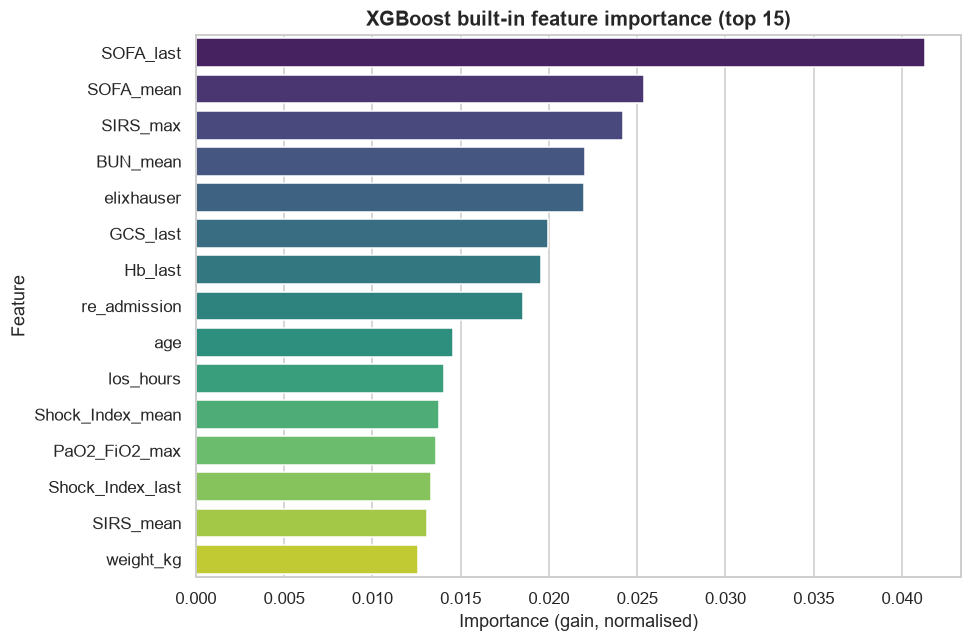

In [4]:
imp = (pd.Series(model.feature_importances_, index=feature_names)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette="viridis",
            legend=False, ax=ax)
ax.set_title("XGBoost built-in feature importance (top 15)", fontsize=13, weight="bold")
ax.set_xlabel("Importance (gain, normalised)")
ax.set_ylabel("Feature")
plt.tight_layout(); plt.show()

### 2. Permutation importance — the more trustworthy one
**Permutation importance** asks a beautifully simple question: *if I shuffle one column and
destroy its information, how much does the model's performance drop?* A feature that really
matters will hurt the AUC when scrambled; a useless one won't.

Why it's more trustworthy: it's measured on the **held-out test set** and reflects the effect
on the metric *you actually care about* (ROC-AUC here), not an internal training-time bookkeeping number.

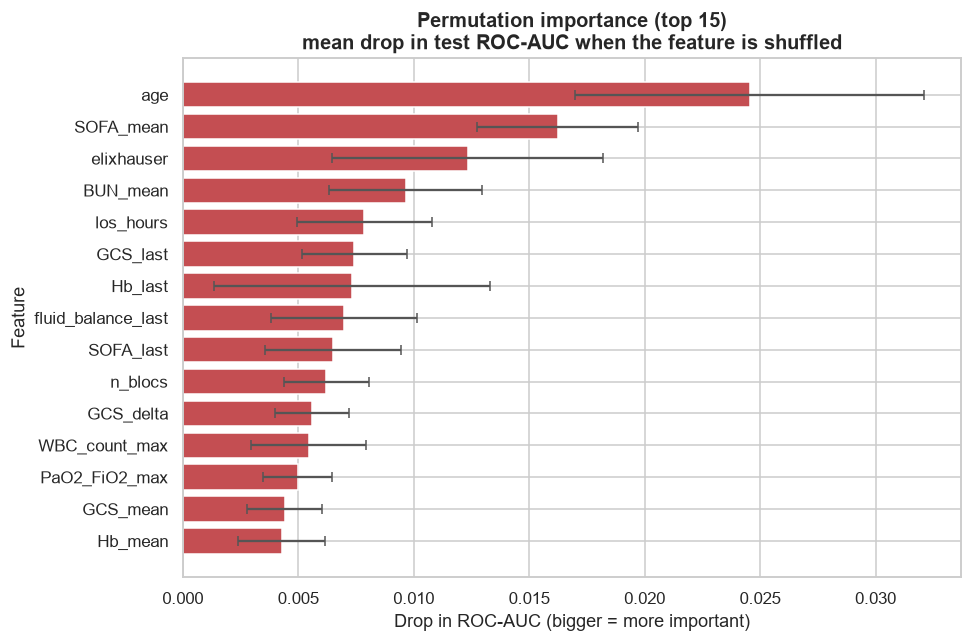

In [5]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    model, X_test, y_test, scoring="roc_auc",
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=2)

perm_imp = (pd.DataFrame({"feature": feature_names,
                          "drop_in_auc": perm.importances_mean,
                          "std": perm.importances_std})
            .sort_values("drop_in_auc", ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_imp["feature"], perm_imp["drop_in_auc"],
        xerr=perm_imp["std"], color="#c44e52", ecolor="#555", capsize=3)
ax.invert_yaxis()
ax.set_title("Permutation importance (top 15)\nmean drop in test ROC-AUC when the feature is shuffled",
             fontsize=13, weight="bold")
ax.set_xlabel("Drop in ROC-AUC (bigger = more important)")
ax.set_ylabel("Feature")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** The two rankings usually *agree at the top* — organ-failure and
> perfusion markers (**SOFA**, **Arterial lactate**, **age**, **BUN/Creatinine**) dominate,
> exactly what a clinician would expect for sepsis mortality. Where they disagree, trust the
> **permutation** version: it's telling you what actually moves the needle on out-of-sample
> performance. But both are still only *rankings* — they don't tell us **which direction** a
> feature pushes risk, or how it differs patient-to-patient. Enter SHAP.

## 🔦 SHAP: a fair split of the credit

**SHAP** (SHapley Additive exPlanations) borrows an idea from cooperative game theory. Think of
the features as players on a team and the prediction as the score. SHAP works out **each
feature's fair share of the credit** for pushing this particular patient's risk above or below
the average patient.

In one sentence: **a SHAP value is how many log-odds of risk a feature added or subtracted for
one patient, relative to the average prediction.** They're *additive* — start at the average,
add up every feature's SHAP value, and you land exactly on this patient's predicted risk.

For tree models there's an exact, fast algorithm: `shap.TreeExplainer`. We'll explain a sample
of ≈300 test patients (plenty for stable pictures, and fast).

In [6]:
import shap

# Cap at ~300 test patients for speed; SHAP is exact for trees so this is plenty.
X_shap = X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(model)
shap_exp = explainer(X_shap)          # an Explanation object: values + base value + data

print("SHAP values shape:", shap_exp.values.shape, "(patients x features)")
print(f"Base value (avg model output, log-odds): {np.ravel(shap_exp.base_values)[0]:.3f}")

SHAP values shape: (300, 104) (patients x features)
Base value (avg model output, log-odds): 0.495


### 🐝 The beeswarm summary plot — read it together

The beeswarm is the single most information-dense plot in ML explainability. Here's the key:

- **One dot = one patient, for one feature.** Rows are features, sorted by overall importance.
- **Horizontal position** = that feature's SHAP value → **right = pushed risk UP**, left = pushed risk DOWN.
- **Colour** = the feature's *value* for that patient → **red = high**, blue = low.

So a row where the **red dots sit on the right** means "high values of this feature increase
predicted mortality". Watch for it on lactate and SOFA.

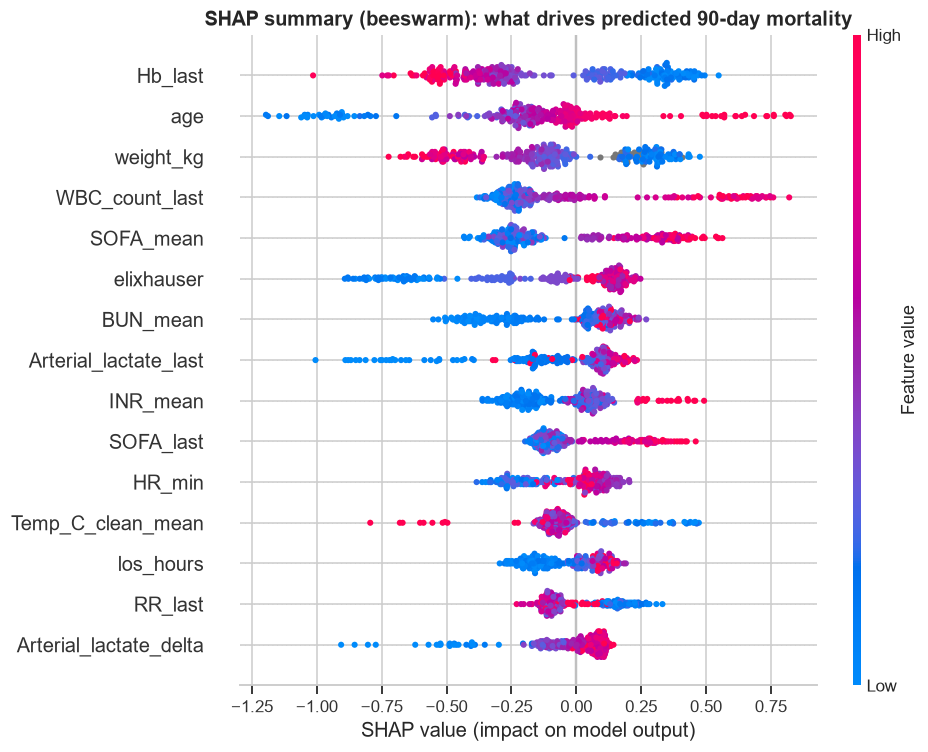

In [7]:
shap.summary_plot(shap_exp.values, X_shap, show=False, max_display=15)
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.title("SHAP summary (beeswarm): what drives predicted 90-day mortality",
          fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** Read off the colour gradients: for **Arterial lactate** and
> **SOFA**, red (high) dots sit to the right — high values raise predicted risk, which is
> physiologically correct (worse tissue perfusion, more organ failure). For **MeanBP** or
> **GCS**, high values (red) tend to sit *left* — a well-perfused, alert patient is lower risk.
> The model has, on its own, rediscovered bedside intuition.

### 📉 Mean |SHAP| bar — a cleaner importance ranking
Averaging the *magnitude* of each feature's SHAP values across patients gives a clean, honest
global importance measure (in the units of the prediction). Compare its order with the two
importance plots above.

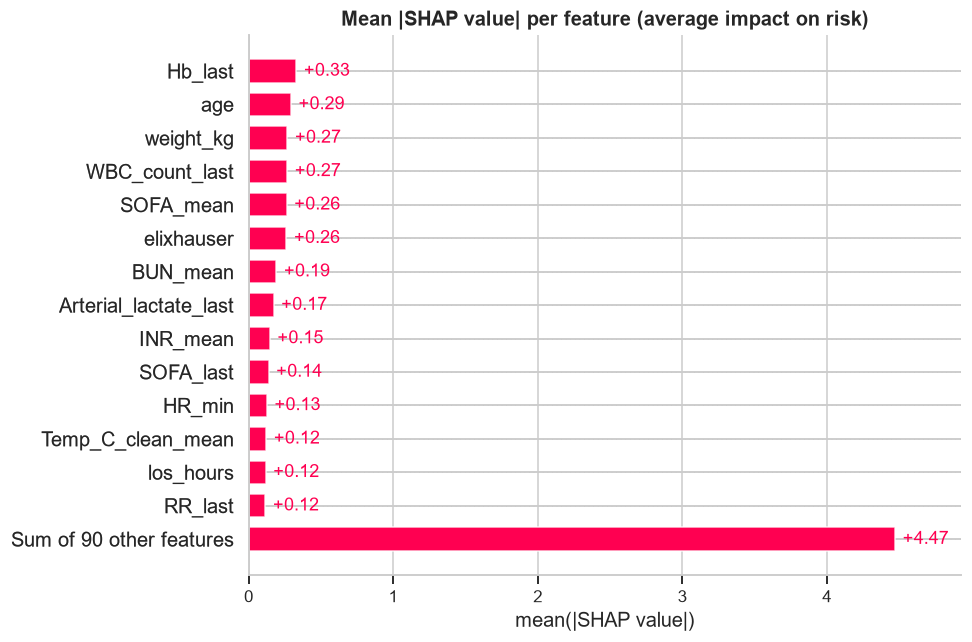

In [8]:
shap.plots.bar(shap_exp, max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.title("Mean |SHAP value| per feature (average impact on risk)",
          fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

## 🧍 Explain ONE patient — the bedside moment

Global plots are for the model developer. The clinician wants to know: **"why did the model
flag *this* patient?"** SHAP's *additivity* makes this exact — the **waterfall** plot starts at
the average prediction and stacks each feature's push until it reaches this patient's risk.

Let's pick the **highest-risk** and **lowest-risk** patients in our SHAP sample.

In [9]:
risk = model.predict_proba(X_shap)[:, 1]
high_i = int(np.argmax(risk))   # position within X_shap / shap_exp
low_i  = int(np.argmin(risk))

print(f"Highest-risk patient: predicted 90-day mortality = {risk[high_i]:.0%}")
print(f"Lowest-risk  patient: predicted 90-day mortality = {risk[low_i]:.0%}")

Highest-risk patient: predicted 90-day mortality = 98%
Lowest-risk  patient: predicted 90-day mortality = 0%


#### 🔴 The high-risk patient — why did the model raise the alarm?
Red bars push risk **up**, blue bars push it **down**. The bars sum from the base value
(average patient) to `f(x)`, this patient's score in log-odds.

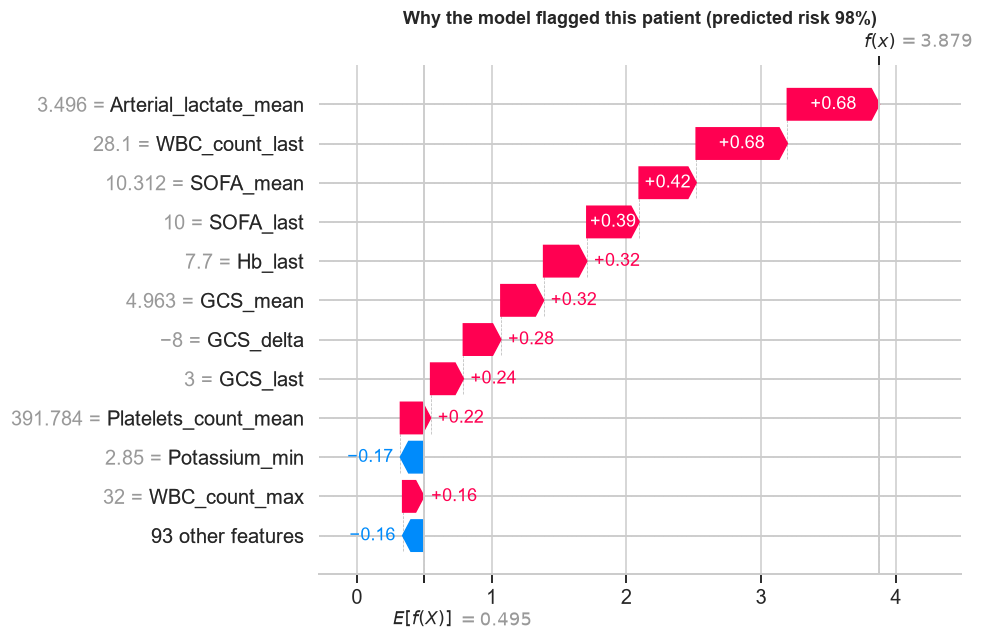

In [10]:
shap.plots.waterfall(shap_exp[high_i], max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.title(f"Why the model flagged this patient (predicted risk {risk[high_i]:.0%})",
          fontsize=12, weight="bold")
plt.tight_layout(); plt.show()

#### 🟢 The low-risk patient — why the model is reassured

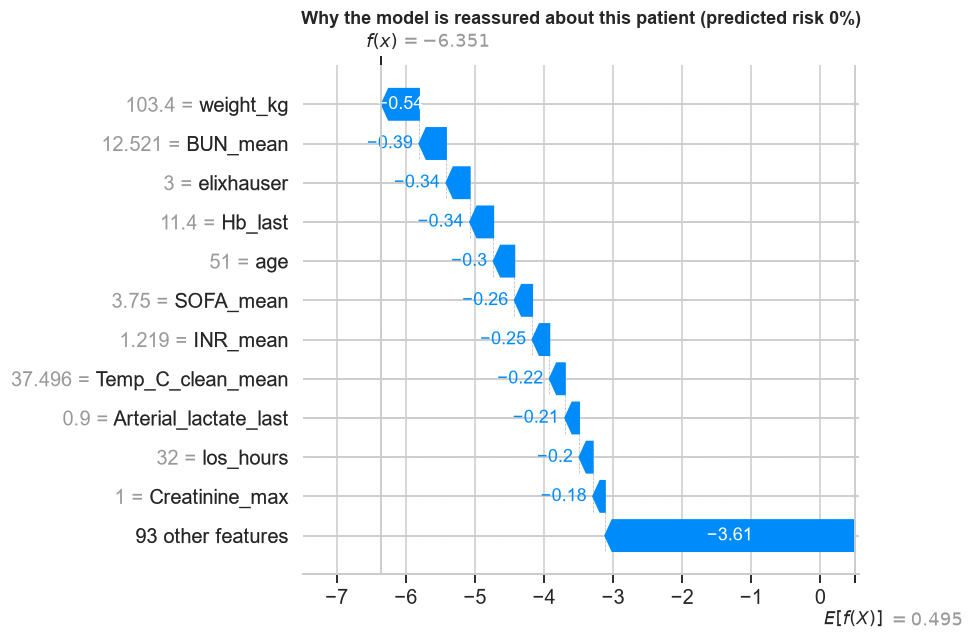

In [11]:
shap.plots.waterfall(shap_exp[low_i], max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
plt.title(f"Why the model is reassured about this patient (predicted risk {risk[low_i]:.0%})",
          fontsize=12, weight="bold")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** This is the plot to show at the bedside or in a morbidity &
> mortality review. Instead of *"the black box said 71%"*, you can say *"the model raised this
> patient's risk mainly because of a **high peak lactate**, a **high SOFA score**, and **age**,
> partially offset by a **preserved blood pressure**."* That is auditable, teachable, and
> challengeable — which is exactly what a safe clinical tool should be.

## 📈 Dependence plot: the *shape* of a risk relationship

A dependence plot puts one feature's **value** on the x-axis and its **SHAP value** on the
y-axis, one dot per patient. It reveals whether the relationship is linear, has a threshold, or
plateaus — and the colour hints at interactions with a second feature.

Let's look at **peak arterial lactate**, the signature sepsis marker.

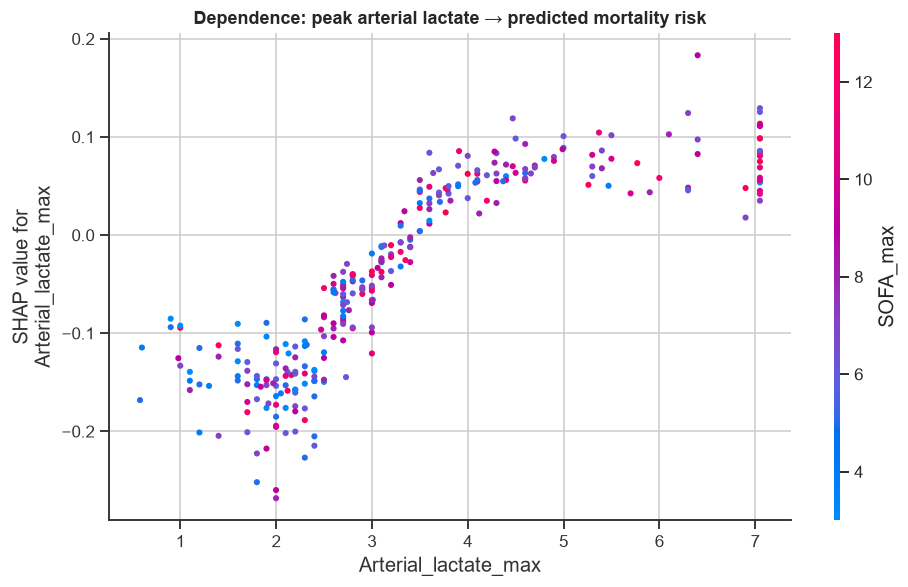

In [12]:
shap.dependence_plot("Arterial_lactate_max", shap_exp.values, X_shap,
                     interaction_index="SOFA_max", show=False)
fig = plt.gcf()
fig.set_size_inches(9, 5.5)
plt.title("Dependence: peak arterial lactate → predicted mortality risk",
          fontsize=12, weight="bold")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** SHAP value climbs steeply as peak lactate rises from ≈2 to ≈6
> mmol/L, then keeps pushing risk up — mirroring the well-known dose-response between
> hyperlactataemia and sepsis mortality. The colour (SOFA) shows the two travel together: high
> lactate rarely comes alone. The model learned a physiologically sensible curve **from data
> alone**, without anyone programming the rule.

## ⚠️ Honest caveats — read before you trust an explanation

SHAP is powerful, but it is not a truth serum. Keep these firmly in mind:

- **SHAP explains the *model*, not the *biology*.** It tells you what the model learned — which
  may be right, wrong, or a shortcut. If the model is biased, SHAP faithfully explains the bias.
- **Correlation ≠ causation.** A feature with a big positive SHAP value is *associated* with the
  outcome in this model; it does **not** mean intervening on it will change the outcome.
  (Lowering a thermometer reading doesn't cure the fever.)
- **Correlated features share credit unpredictably.** `SOFA`, `lactate`, `Creatinine` and `BUN`
  all move together in sepsis; SHAP splits credit among them in ways that can shift if you
  add/remove a redundant feature. Don't over-interpret the exact ranking of correlated markers.
- **Out-of-distribution = out of its depth.** These explanations are only valid for patients who
  resemble the training data. On a different hospital, a different case-mix, or an unusual
  patient, both the prediction *and* its explanation can be misleading.
- **Explaining ≠ validating.** A beautiful SHAP story does not prove the model is safe. It's a
  tool for **auditing and building trust**, used *alongside* the evaluation from Notebook 06,
  not instead of it.

## ✏️ Your turn

Work through these to cement the ideas. Each has a collapsible solution — try first, then peek.

### Exercise 1 — Rank features by mean |SHAP|
The beeswarm/bar plots are pretty, but sometimes you just want the numbers. Using the raw SHAP
array `shap_exp.values`, compute each feature's **mean absolute SHAP value** and print the
**top 10** as a tidy `Series`. *(Hint: `np.abs(...).mean(axis=0)`, then wrap in a `pd.Series`
indexed by `feature_names`.)*

In [13]:
# TODO: compute mean |SHAP| per feature and show the top 10
# mean_abs = ...
# print(...)


<details><summary>💡 Show solution</summary>

```python
mean_abs = (pd.Series(np.abs(shap_exp.values).mean(axis=0), index=feature_names)
              .sort_values(ascending=False))
print(mean_abs.head(10).round(3))
```
</details>

### Exercise 2 — Explain a patient of your choosing
Pick the patient in `X_shap` with the **highest peak lactate** (`Arterial_lactate_max`) and draw
their SHAP **waterfall** plot. Does lactate dominate their explanation? *(Hint:
`X_shap["Arterial_lactate_max"].to_numpy().argmax()` gives the row position to feed into
`shap_exp[...]`.)*

In [14]:
# TODO: find the highest-lactate patient in X_shap and plot their waterfall
# pos = ...
# shap.plots.waterfall(shap_exp[pos], show=False); plt.show()


<details><summary>💡 Show solution</summary>

```python
pos = int(X_shap["Arterial_lactate_max"].to_numpy().argmax())
print("Peak lactate:", round(float(X_shap["Arterial_lactate_max"].iloc[pos]), 1),
      "mmol/L | predicted risk:", f"{model.predict_proba(X_shap)[:,1][pos]:.0%}")
shap.plots.waterfall(shap_exp[pos], max_display=12, show=False)
plt.tight_layout(); plt.show()
```
</details>

### Exercise 3 — A dependence plot for age
Draw a `shap.dependence_plot` for **`age`** (colour the interaction automatically by passing
`interaction_index="auto"`). Is the age → risk relationship roughly monotonic? Where does the
risk contribution cross zero (the age at which a patient is "average")?

In [15]:
# TODO: dependence plot for age
# shap.dependence_plot("age", ..., ..., interaction_index="auto", show=False)
# plt.show()


<details><summary>💡 Show solution</summary>

```python
shap.dependence_plot("age", shap_exp.values, X_shap,
                     interaction_index="auto", show=False)
plt.title("Dependence: age → predicted mortality risk", weight="bold")
plt.tight_layout(); plt.show()
```
Age has a broadly increasing, near-monotonic effect; the SHAP contribution crosses zero near the
cohort's mean age, and older patients receive a positive (risk-raising) push.
</details>

## ✅ Recap

- **Two global importances.** Built-in tree importance is free but biased; **permutation
  importance** (drop in test AUC when a feature is shuffled) is more trustworthy. They agree at
  the top: SOFA, lactate, age, renal markers.
- **SHAP** fairly attributes each feature's push on a *single* prediction, and the pushes add up
  exactly to the model's output — global *and* local explanations from one framework.
- **Beeswarm** = direction + magnitude for the whole cohort (red-right = high value raises risk).
  **Waterfall** = the per-patient story you can defend at the bedside. **Dependence** = the shape
  of a single risk relationship.
- **Caveats matter.** SHAP explains the *model*, not the biology; correlation isn't causation;
  correlated markers share credit; and none of it replaces honest evaluation.

## ➡️ Next

**Notebook 08 — "How to fool yourself (and how not to)"** turns to the ways a model can look
brilliant and be worthless: patient overlap between train and test, scaling before the split,
target leakage, and tuning on the test set. Each is shown as a **before (inflated) vs after
(honest)** number — essential reading before anyone trusts a model like the one we just explained.

*Well done — you can now open the black box and, just as importantly, know the limits of what
you see inside.* 🩺